### Install all required libraries on top of the rapids image

In [ ]:
%%capture
!pip install pytorch
!pip install torchvision 
!pip install torchsummary
!pip install imblearn
!pip install mlxtend
!pip install opencv-python
!apt-get install libgl1 --yes
!pip install onnx

### Import all required libraries. CV2 is not utlized but is being imported for testing the snowflake udf

In [10]:
import os
import random
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
%matplotlib inline

import cv2
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

from PIL import *
from tqdm import tqdm
from torchsummary import summary
from torchvision import datasets, transforms
from torch.utils.data import  DataLoader, Dataset, ConcatDataset
from sklearn.model_selection import train_test_split

### Include gpus/multigpus when using the snowpark container services

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


### Unzip the chest xray dataset and save it on the disk

In [27]:
%%capture
!unzip data/chest_xray.zip

In [28]:
train_folder= 'chest_xray/chest_xray/train/'
val_folder = 'chest_xray/chest_xray/val/'
test_folder = 'chest_xray/chest_xray/test/'

### Define Data Augmentation on the DICOM images (jpegs)

In [29]:
data_transforms = {
    'train': {
        'dataset1': transforms.Compose([transforms.Resize(255),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.RandomGrayscale(),
            transforms.RandomAffine(translate=(0.05,0.05), degrees=0),
            transforms.ToTensor()
           ]),

        'dataset2' : transforms.Compose([transforms.Resize(255),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=1),
            transforms.RandomGrayscale(),
            transforms.RandomAffine(translate=(0.1,0.05), degrees=10),
            transforms.ToTensor()

           ]),
        'dataset3' : transforms.Compose([transforms.Resize(255),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.RandomGrayscale(p=1),
            transforms.RandomAffine(translate=(0.08,0.1), degrees=15),
            transforms.ToTensor()
           ]),
    },
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

### Split and randomize datasets for training

In [30]:
dataset1 = datasets.ImageFolder(train_folder, 
                      transform=data_transforms['train']['dataset1'])

dataset2 = datasets.ImageFolder(train_folder, 
                      transform=data_transforms['train']['dataset2'])

dataset3 = datasets.ImageFolder(train_folder, 
                      transform=data_transforms['train']['dataset3'])

norm1, _ = train_test_split(dataset2, test_size= 0.75, shuffle=False)
norm2, _ = train_test_split(dataset3, test_size= 0.77, shuffle=False)

In [31]:
dataset = ConcatDataset([dataset1, norm1, norm2])

In [32]:
train_ds, val_ds = train_test_split(dataset, test_size=0.3, random_state=2000)

In [33]:
Datasets = {
    'train': train_ds,
    'test' : datasets.ImageFolder(test_folder, data_transforms['test']),
    'val'  : val_ds
}

### Define Dataloaders for Train, Test and Validate

In [34]:
Dataloaders = {
    'train': DataLoader(Datasets['train'], batch_size = 512, num_workers = 4),
    'test': DataLoader(Datasets['test'], batch_size = 512, shuffle = True, num_workers = 4),
    'val': DataLoader(Datasets['val'], batch_size = 512, shuffle = True, num_workers = 4),
}

### Build Statistics on the dataset. Especially make sure it is balanced dataset

In [35]:
files = []
categories = []
filenames = os.listdir(os.path.join(train_folder,'NORMAL'))
for name in filenames:
    files.append(os.path.join(train_folder, 'NORMAL', name))
    categories.append('NORMAL')

filenames = os.listdir(os.path.join(train_folder,'PNEUMONIA'))
for name in filenames:
    files.append(os.path.join(train_folder, 'PNEUMONIA', name))
    categories.append('PNEUMONIA')

In [36]:
Tr_PNEUMONIA = len([label for _, label in Datasets['train'] if label == 1])
Tr_NORMAL = len(Datasets['train']) - Tr_PNEUMONIA
V_PNEUMONIA = len([label for _, label in Datasets['val'] if label == 1])
V_NORMAL = len(Datasets['val']) - V_PNEUMONIA
Te_PNEUMONIA = len([label for _, label in Datasets['test'] if label == 1])
Te_NORMAL = len(Datasets['test']) - Te_PNEUMONIA
Pn = [Tr_PNEUMONIA, V_PNEUMONIA, Te_PNEUMONIA]
No = [Tr_NORMAL, V_NORMAL, Te_NORMAL]
Pn, No

([2718, 1157, 390], [2685, 1159, 234])

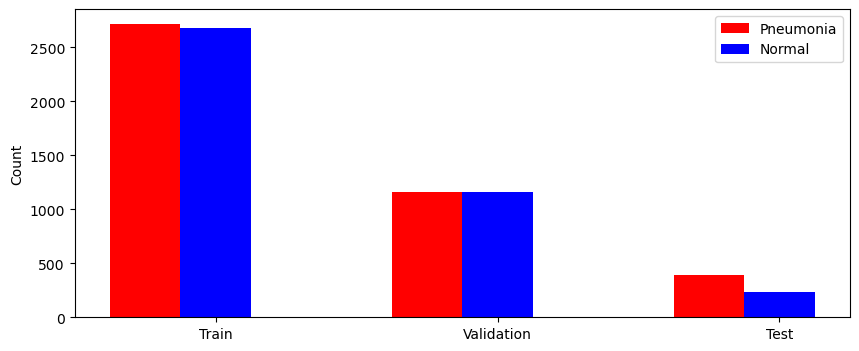

In [37]:
fig = plt.subplots(figsize =(10, 4))

br1 = np.arange(len(Pn))
br2 = [x + 0.25 for x in br1]

plt.bar(br1, Pn, color='r', width = 0.25, label = 'Pneumonia')
plt.bar(br2, No, color='b', width = 0.25, label = 'Normal')

plt.ylabel('Count')
plt.xticks([r + 0.25 for r in range(len(Pn))],
        ['Train', 'Validation', 'Test'])
plt.legend()
plt.show()

### Define the Model using pretrained models (resnet18, vgg16 etc)

In [39]:
model = torchvision.models.resnet18(pretrained=True)
#model = torchvision.models.vgg16(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, 2)
)
model= nn.DataParallel(model)
model.to(device)
summary(model, input_size = (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
            Conv2d-2         [-1, 64, 112, 112]           9,408
       BatchNorm2d-3         [-1, 64, 112, 112]             128
              ReLU-4         [-1, 64, 112, 112]               0
         MaxPool2d-5           [-1, 64, 56, 56]               0
            Conv2d-6           [-1, 64, 56, 56]          36,864
       BatchNorm2d-7           [-1, 64, 56, 56]             128
              ReLU-8           [-1, 64, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          36,864
      BatchNorm2d-10           [-1, 64, 56, 56]             128
             ReLU-11           [-1, 64, 56, 56]               0
       BasicBlock-12           [-1, 64, 56, 56]               0
           Conv2d-13           [-1, 64, 56, 56]          36,864
      BatchNorm2d-14           [-1, 64,

### Define Trainer, Validation Loop

In [67]:
def trainer_loop(model, 
                 trainloader, 
                 loss_fn, 
                 optimizer, 
                 scheduler = None, 
                 t_gpu = True):
    model.train()
    tr_loss, tr_acc = 0.0, 0.0
    for i, data in enumerate(tqdm(trainloader)):
        img, label = data
        if t_gpu:
                img, label = img.cuda(), label.cuda()
        optimizer.zero_grad()
        output = model(img)
        _, pred = torch.max(output.data, 1)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()
        
        tr_loss += loss.item()
        tr_acc += torch.sum(pred == label.data)
        torch.cuda.empty_cache()

    scheduler.step() if scheduler != None else None
    return tr_loss/len(trainloader.dataset), 100*tr_acc/len(trainloader.dataset)

In [68]:
def val_loop(model, val_loader, loss_fn, t_gpu=True):
    model.train(False)
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for i, data in enumerate(tqdm(val_loader)):
            img, label = data
            if t_gpu:
                    img, label = img.cuda(), label.cuda()
            output = model(img)
            _, pred = torch.max(output.data, 1)
            loss = loss_fn(output, label)

            val_loss += loss.item()
            val_acc += torch.sum(pred == label.data)

    return val_loss/len(val_loader.dataset), 100*val_acc/len(val_loader.dataset)

In [69]:
def train_model(epochs, 
                model, 
                trainloader, 
                valloader, 
                loss_fn, 
                optimizer, 
                scheduler = None, 
                t_gpu = True):
    stat_dict = {
        'learning_rate':[],
        'train_loss':    [],
        'train_acc':     [],
        'val_loss':      [],
        'val_acc':       []    
    }
    print('*'*5+'Training Started'+'*'*5)
    for ep in range(epochs):
        print(f'Training epoch: {ep+1}')
        t_loss, t_acc = trainer_loop(
            model, trainloader, loss_fn, optimizer, scheduler, t_gpu
        )
        v_loss, v_acc = val_loop(
            model, valloader, loss_fn, t_gpu
        )
        print(f'Learning Rate: {optimizer.param_groups[0]["lr"]}')
        print(f'Training   : Loss: {t_loss}    Accuracy: {t_acc}%')
        print(f'Validation : Loss: {v_loss}    Accuracy: {v_acc}%')
        stat_dict['learning_rate'].append(optimizer.param_groups[0]["lr"])
        stat_dict['train_loss'].append(t_loss)
        stat_dict['val_loss'].append(v_loss)
        stat_dict['train_acc'].append(t_acc)
        stat_dict['val_acc'].append(v_acc)
    print('Finished Training')
    return stat_dict

### Define the Model parameters and execute the model on cuda

In [81]:
epochs = 100
alpha = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=alpha)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 
                                            step_size = 3, 
                                            gamma = 0.1)
loss_fn = nn.CrossEntropyLoss()

hist = train_model(epochs, 
                   model, 
                   Dataloaders['train'], 
                   Dataloaders['val'], 
                   loss_fn, 
                   optimizer,  
                   scheduler, 
                   device == 'cuda')

*****Training Started*****
Training epoch: 1


100%|██████████| 73/73 [00:02<00:00, 28.92it/s]


Learning Rate: 0.001
Training   : Loss: 0.0031501595105844177    Accuracy: 96.57597351074219%
Validation : Loss: 0.0019336178969585423    Accuracy: 97.7115707397461%
Training epoch: 2


100%|██████████| 73/73 [00:02<00:00, 29.31it/s]


Learning Rate: 0.001
Training   : Loss: 0.0018930629385035748    Accuracy: 97.92707824707031%
Validation : Loss: 0.0034503746883934026    Accuracy: 96.50259399414062%
Training epoch: 3


...

Learning Rate: 1.0000000000000019e-35
Training   : Loss: 0.0002045108529747442    Accuracy: 99.96298217773438%
Validation : Loss: 0.0016893791581456998    Accuracy: 98.10017395019531%
Training epoch: 99


100%|██████████| 73/73 [00:02<00:00, 29.43it/s]


Learning Rate: 1.000000000000002e-36
Training   : Loss: 0.00020816844653003103    Accuracy: 99.94447326660156%
Validation : Loss: 0.0016896966391903331    Accuracy: 98.10017395019531%
Training epoch: 100


100%|██████████| 73/73 [00:02<00:00, 28.14it/s]

Learning Rate: 1.000000000000002e-36
Training   : Loss: 0.00017018916834035983    Accuracy: 99.96298217773438%
Validation : Loss: 0.0016894867129596544    Accuracy: 98.10017395019531%
Finished Training


### Plot Train and Validation Loss

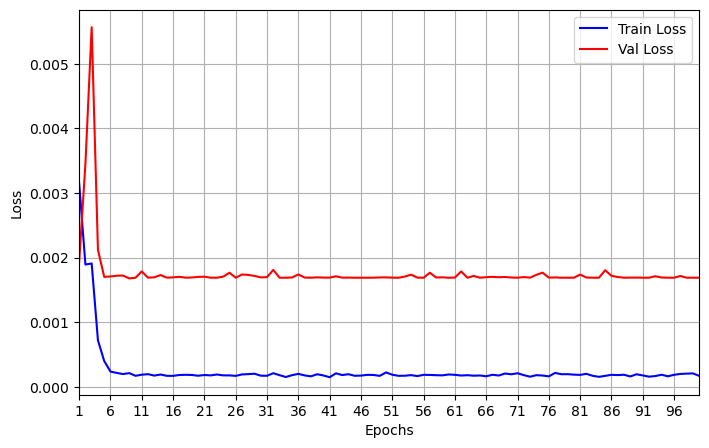

In [82]:
fig, ax = plt.subplots(figsize=(8,5))

LT = ax.plot(np.linspace(1, epochs, epochs), hist['train_loss'], 'b-', label='Train Loss')
LV = ax.plot(np.linspace(1, epochs, epochs), hist['val_loss'], 'r-', label='Val Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

ax.set_xlim([1, (len(hist['val_loss']))])
if len(hist['val_loss']) >= 30:
    ax.set_xticks(range(1, (len(hist['val_loss'])+1), 5))
elif len(hist['val_loss']) >= 20:
    ax.set_xticks(range(1, (len(hist['val_loss'])+1), 2))
elif len(hist['val_loss']) < 20:
    ax.set_xticks(range(1, (len(hist['val_loss'])+1)))

lns = LT+LV
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper right')
ax.grid('on')

### Plot Train and Validation Accuracy

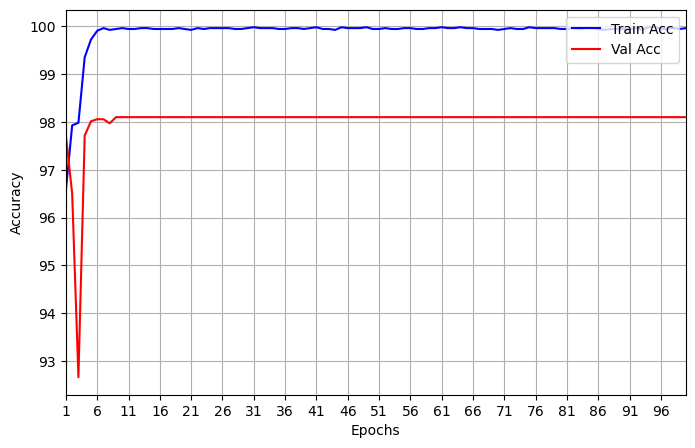

In [83]:
fig, ax = plt.subplots(figsize=(8,5))

hist_train = [hist['train_acc'][x].item() for x in range(len(hist['train_acc']))]
hist_val = [hist['val_acc'][x].item() for x in range(len(hist['val_acc']))]


AT = ax.plot(np.linspace(1, epochs, epochs), hist_train, 'b-', label='Train Acc')
AV = ax.plot(np.linspace(1, epochs, epochs), hist_val, 'r-', label='Val Acc')

ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy')

ax.set_xlim([1, (len(hist['val_acc']))])
if len(hist['val_acc']) >= 30:
    ax.set_xticks(range(1, (len(hist['val_acc'])+1), 5))
elif len(hist['val_acc']) >= 20:
    ax.set_xticks(range(1, (len(hist['val_acc'])+1), 2))
elif len(hist['val_acc']) < 20:
    ax.set_xticks(range(1, (len(hist['val_acc'])+1)))

lns = AT+AV
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper right')
ax.grid('on')

### Inference on Test Data

In [84]:
@torch.no_grad()
def test_loop(model, testdata, loss_fn, t_gpu):
    print('*'*5+'Testing Started'+'*'*5)
    model.train(False)
    model.eval()
    
    full_pred, full_lab = [], []
    
    TestLoss, TestAcc = 0.0, 0.0
    for data, target in testdata:
        if t_gpu:
            data, target = data.cuda(), target.cuda()

        output = model(data)
        loss = loss_fn(output, target)

        _, pred = torch.max(output.data, 1)
        TestLoss += loss.item() * data.size(0)
        TestAcc += torch.sum(pred == target.data)
        torch.cuda.empty_cache()
        full_pred += pred.tolist()
        full_lab += target.data.tolist()

    TestLoss = TestLoss / len(testdata.dataset)
    TestAcc = TestAcc / len(testdata.dataset)
    print(f'Loss: {TestLoss} Accuracy: {TestAcc}%')
    return full_pred, full_lab

In [85]:
testset = datasets.ImageFolder(test_folder, 
                           transform=transforms.Compose([transforms.Resize(255),
                                                 transforms.CenterCrop(224),                                                              
                                                 transforms.ToTensor(),
                                                ]))
test_dl = DataLoader(testset, batch_size=32)

In [86]:
pred, lab = test_loop(model, test_dl, loss_fn, True)

*****Testing Started*****
Loss: 0.3443414898445973 Accuracy: 0.9038461446762085%


### Look at the confusion matrix from the Test data prediction versus Actual labels.

<Figure size 640x480 with 0 Axes>

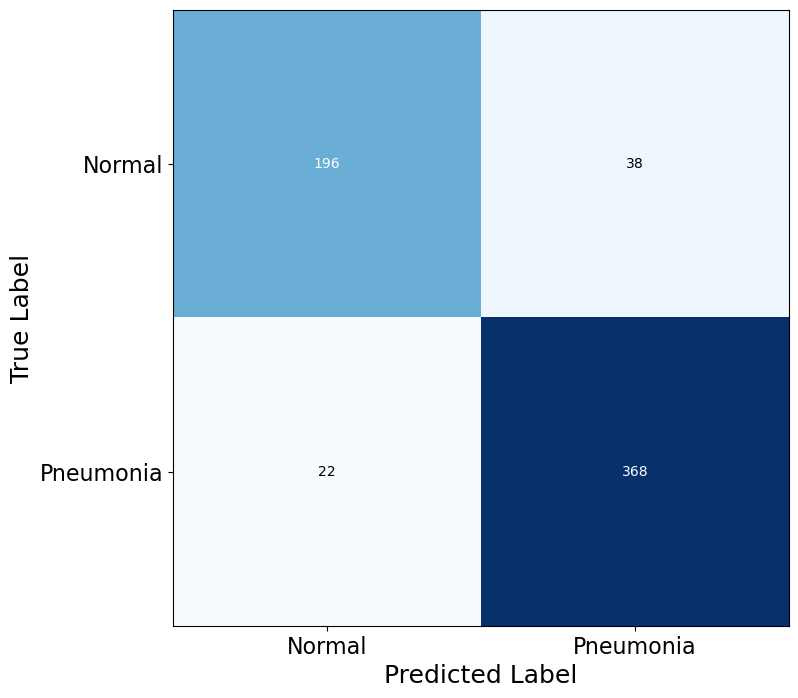

In [87]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

cm  = confusion_matrix(lab, pred)
plt.figure()
plot_confusion_matrix(cm,figsize=(12,8),cmap=plt.cm.Blues)
plt.xticks(range(2), ['Normal', 'Pneumonia'], fontsize=16)
plt.yticks(range(2), ['Normal', 'Pneumonia'], fontsize=16)
plt.xlabel('Predicted Label',fontsize=18)
plt.ylabel('True Label',fontsize=18)
plt.show()

### Get the Model Accuracy, Recall, Precision and F1 Score of the Model

In [88]:
tn, fp, fn, tp = cm.ravel()

accuracy = (np.array(pred) == np.array(lab)).sum() / len(pred)
precision = tp/(tp+fp)
recall = tp/(tp+fn)
f1 = 2*((precision*recall)/(precision+recall))

print("Accuracy of the model is {:.2f}".format(accuracy))
print("Recall of the model is {:.2f}".format(recall))
print("Precision of the model is {:.2f}".format(precision))
print("F1 Score of the model is {:.2f}".format(f1))

Accuracy of the model is 0.90
Recall of the model is 0.94
Precision of the model is 0.91
F1 Score of the model is 0.92


### Save the Trained Model

In [89]:
torch.save(model.state_dict(), 'pneumonia_detection.pt')

In [93]:
import onnx
model.eval()
dummy_input,_ = next(iter(Dataloaders['test']))
torch.onnx.export(model.module,
         dummy_input.cuda(),
         "pneumonia_detection.onnx",
         export_params=True,
         opset_version=10,
         do_constant_folding=True,
         input_names = ['modelInput'],
         output_names = ['modelOutput'],
         dynamic_axes={'modelInput' : {0 : 'batch_size'},
                                'modelOutput' : {0 : 'batch_size'}}) 
print(" ") 
print('Model has been converted to ONNX')

============= Diagnostic Run torch.onnx.export version 2.0.1+cu117 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

 
Model has been converted to ONNX
